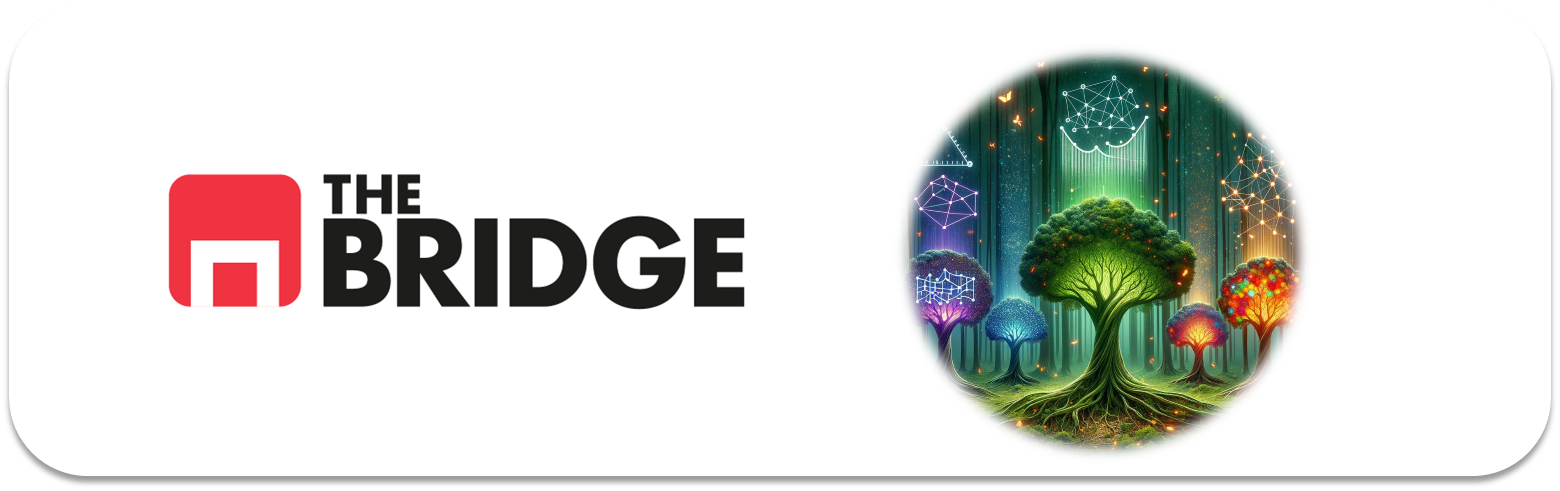

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

%matplotlib inline
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

pd.options.mode.copy_on_write= True

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

In [2]:
df = pd.read_csv("./data/bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianamente razonado
- Comparar con el modelo baseline
- Evaluar contra test

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  IMPAGO DE CRÉDITO    
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  PRÉSTAMO HIPOTECARIO  
   8 - loan: has personal loan? (binary: "yes","no")   PRÉSTAMO PERSONAL  

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")  RESULTADO DE LA CAMPAÑA ANTERIOR.  

  

In [4]:
import toolbox_ML
from toolbox_ML import describe_df
describe_df(df)

,data_type,valores_nulos,valores_unicos,cardinalidad_ptg
age,numerica,0.0,77,0.17
job,categorica,0.0,12,0.03
marital,categorica,0.0,3,0.01
education,categorica,0.0,4,0.01
default,categorica,0.0,2,0.0
balance,numerica,0.0,7168,15.85
housing,categorica,0.0,2,0.0
loan,categorica,0.0,2,0.0
contact,categorica,0.0,3,0.01
day,numerica,0.0,31,0.07


In [5]:
df.drop_duplicates(inplace=True)
print(f'Tamaño del dataset después de eliminar las filas repetidas: {df.shape}')

Tamaño del dataset después de eliminar las filas repetidas: (45211, 17)


In [6]:
features_num = df.select_dtypes(include=np.number).columns

features_cat = df.select_dtypes(include='object').columns.drop("y")

target = "y"

In [7]:
# Mi código : features_bin = df[features_cat].unique() == 2   ---> MAL
# features_cat = features_cat - features_bin

features_bin = features_cat[df[features_cat].nunique() == 2]
features_cat = features_cat.drop(features_bin)

In [8]:
print("Valores del target: ",df[target].unique())
print(features_num)
print(features_cat)
print(features_bin)

Valores del target:  ['no' 'yes']
Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')
Index(['job', 'marital', 'education', 'contact', 'month', 'poutcome'], dtype='object')
Index(['default', 'housing', 'loan'], dtype='object')


In [9]:
print(df.describe())

                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       -1.000000      0.

El target es la columna "y", donde nos dicen si/no comprará el depósito a plazo.  
Está desequilibrado.

In [10]:
print(df[target].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, stratify= df["y"], test_size= 0.2, random_state=42)

In [12]:
print(train_set.shape)
print(test_set.shape)

(36168, 17)
(9043, 17)


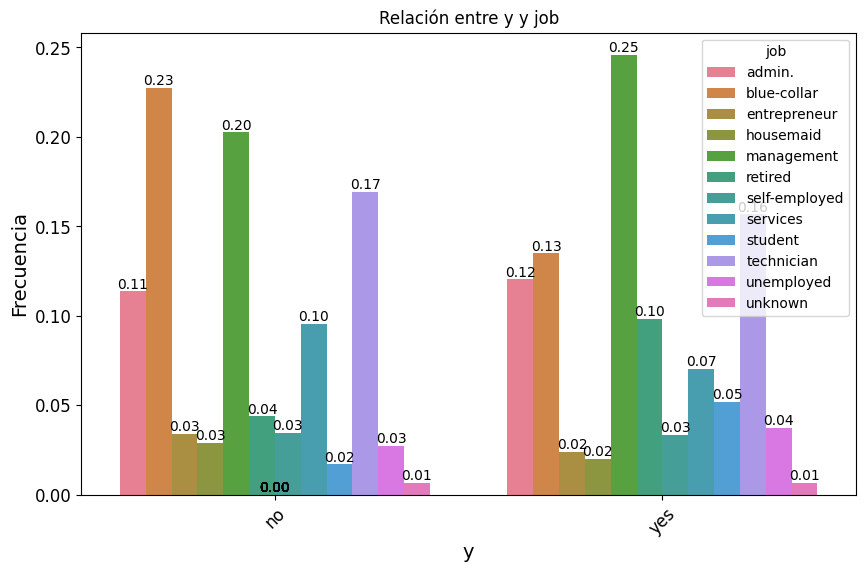

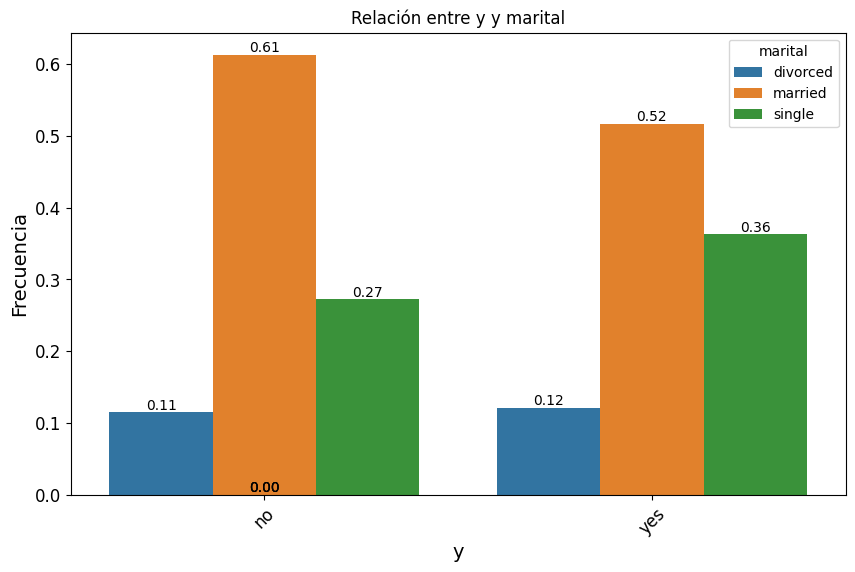

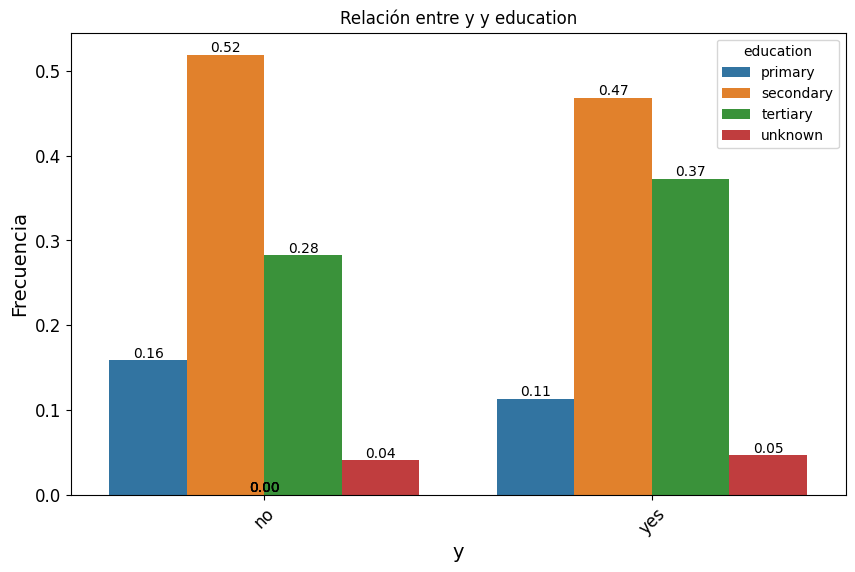

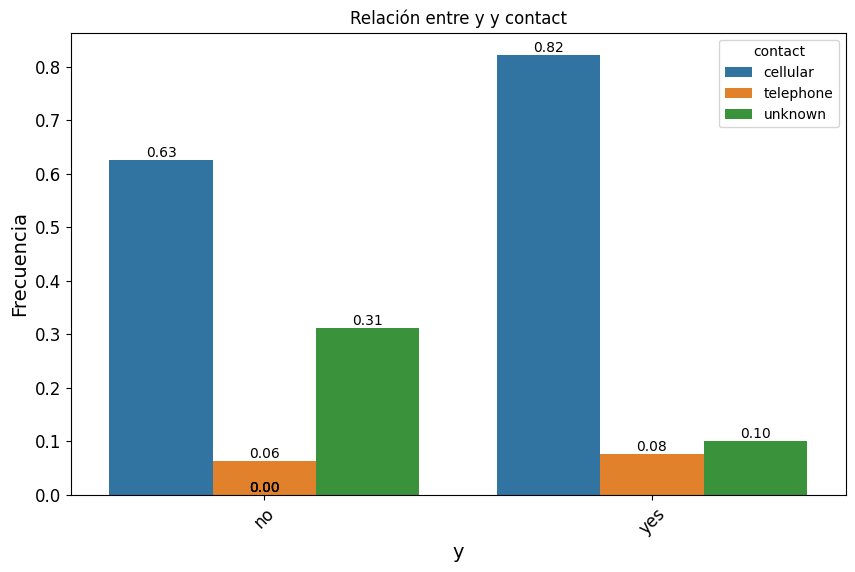

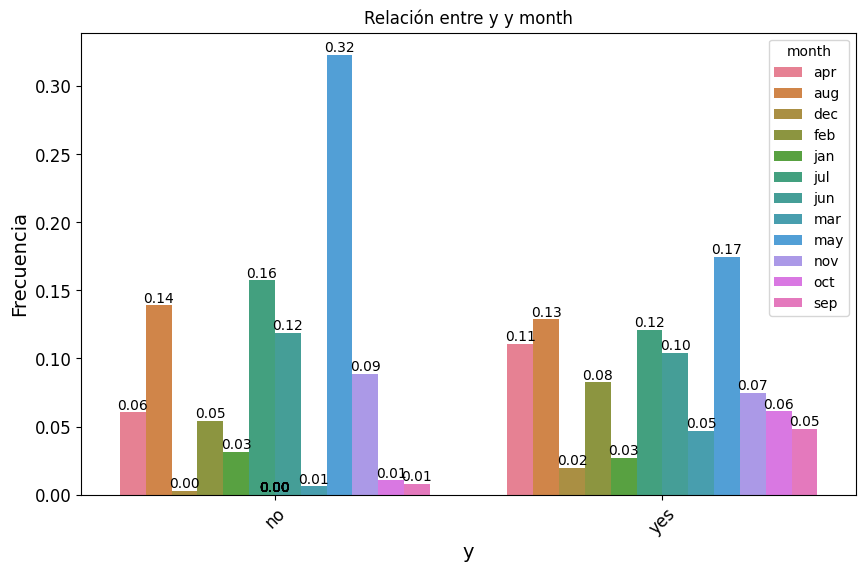

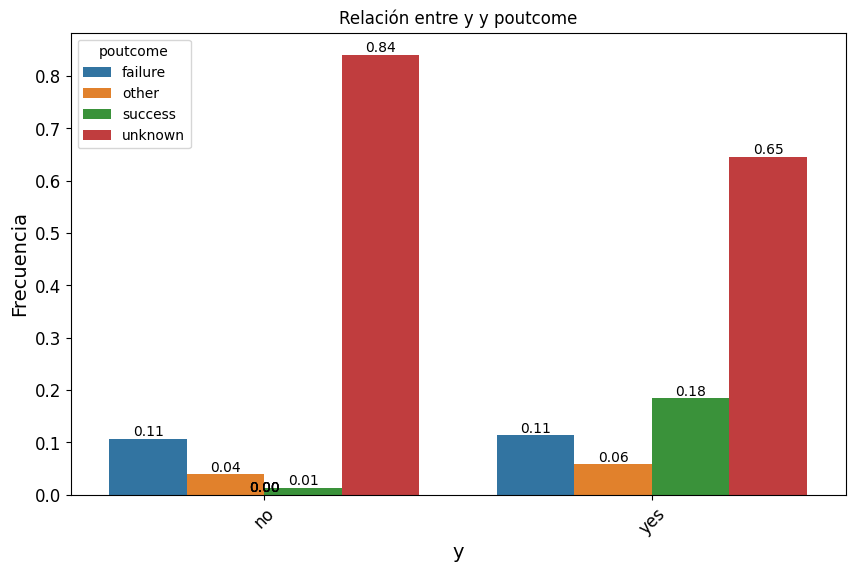

In [13]:
import bootcampviztools as bt
for feat in features_cat:
    bt.plot_categorical_relationship_fin(train_set, target, feat, show_values= True, relative_freq= True);

El trabajo de las personas con más contactos son : obreros, gestores y técnicos. Entre estos los obreros dicen más no y los gestores contestán más si.  
Los solteros dicen que si y los casados que no.  
Las dos priméras etapas educativas dicen que no, com mayor nivel de estudio si.  
Al contactar al posible cliente por teléfono movil hay mayor posibilidad de si.  
Respecto al mes, parece que la relación entre si/no es estable, la cantidad de cada tiene que ver con la cantidad de llamadas. Parece que algunos meses de menor número de llamadas el porcetaje de si es mucho mayor ¿Campaña más dirigida a un target concreto?  
En la mayoría de casos no sabemos si anteriormente dijeron si/no.  
Las personas que tienen hipóteca o préstamo personal dicen no.  
No hay deiferencias en la respuesta entre aquellos que tienen impagos y no los tienen. Vamos a quitar la columna "default".


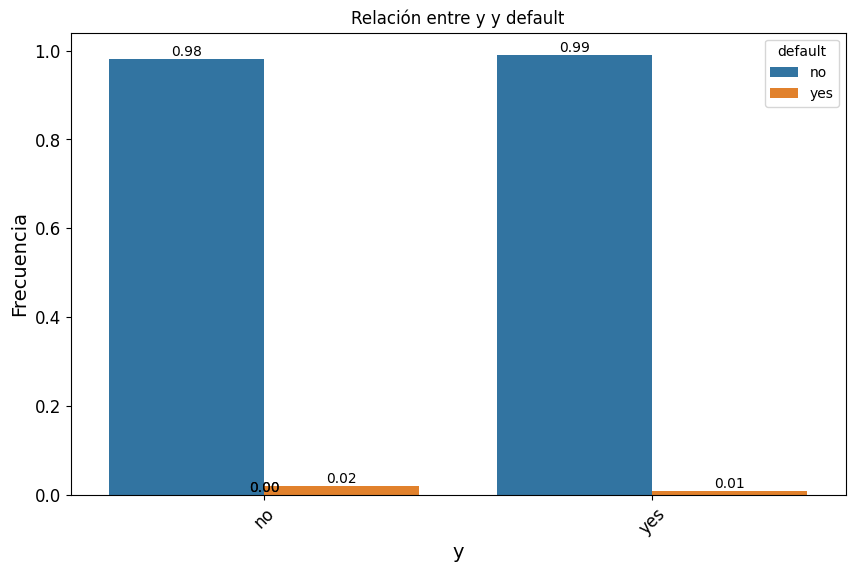

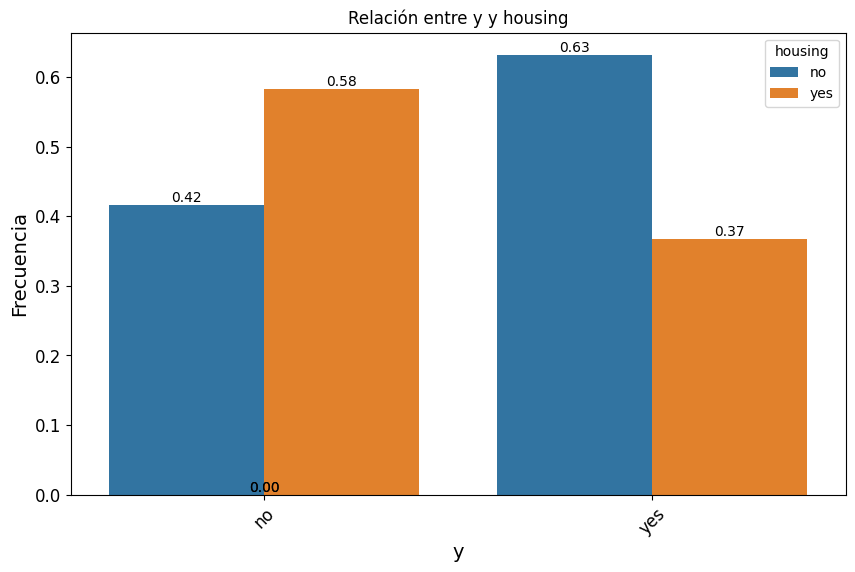

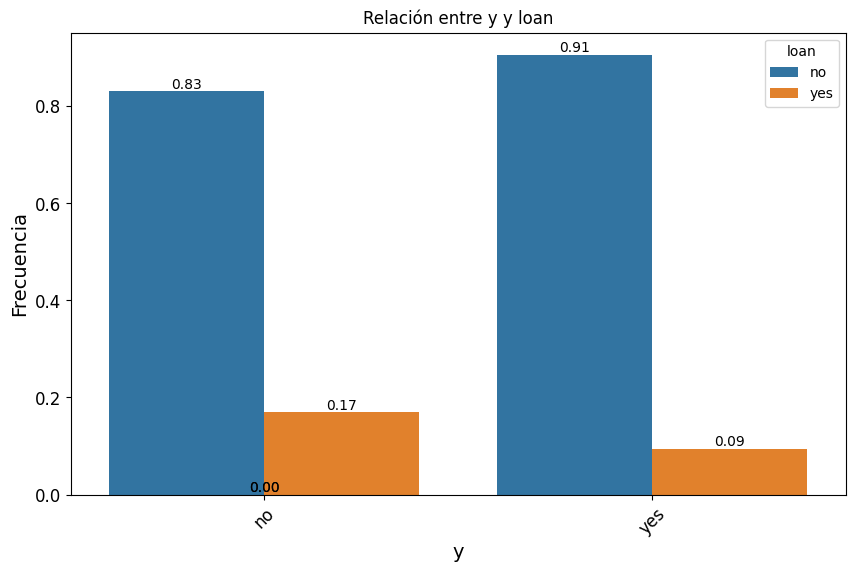

In [14]:
for feat in features_bin:
    bt.plot_categorical_relationship_fin(train_set, target, feat, show_values= True, relative_freq= True);

In [15]:
features_bin = features_bin.drop("default")
print("Valores del target: ",df[target].unique())
print(features_num)
print(features_cat)
print(features_bin)

Valores del target:  ['no' 'yes']
Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')
Index(['job', 'marital', 'education', 'contact', 'month', 'poutcome'], dtype='object')
Index(['housing', 'loan'], dtype='object')


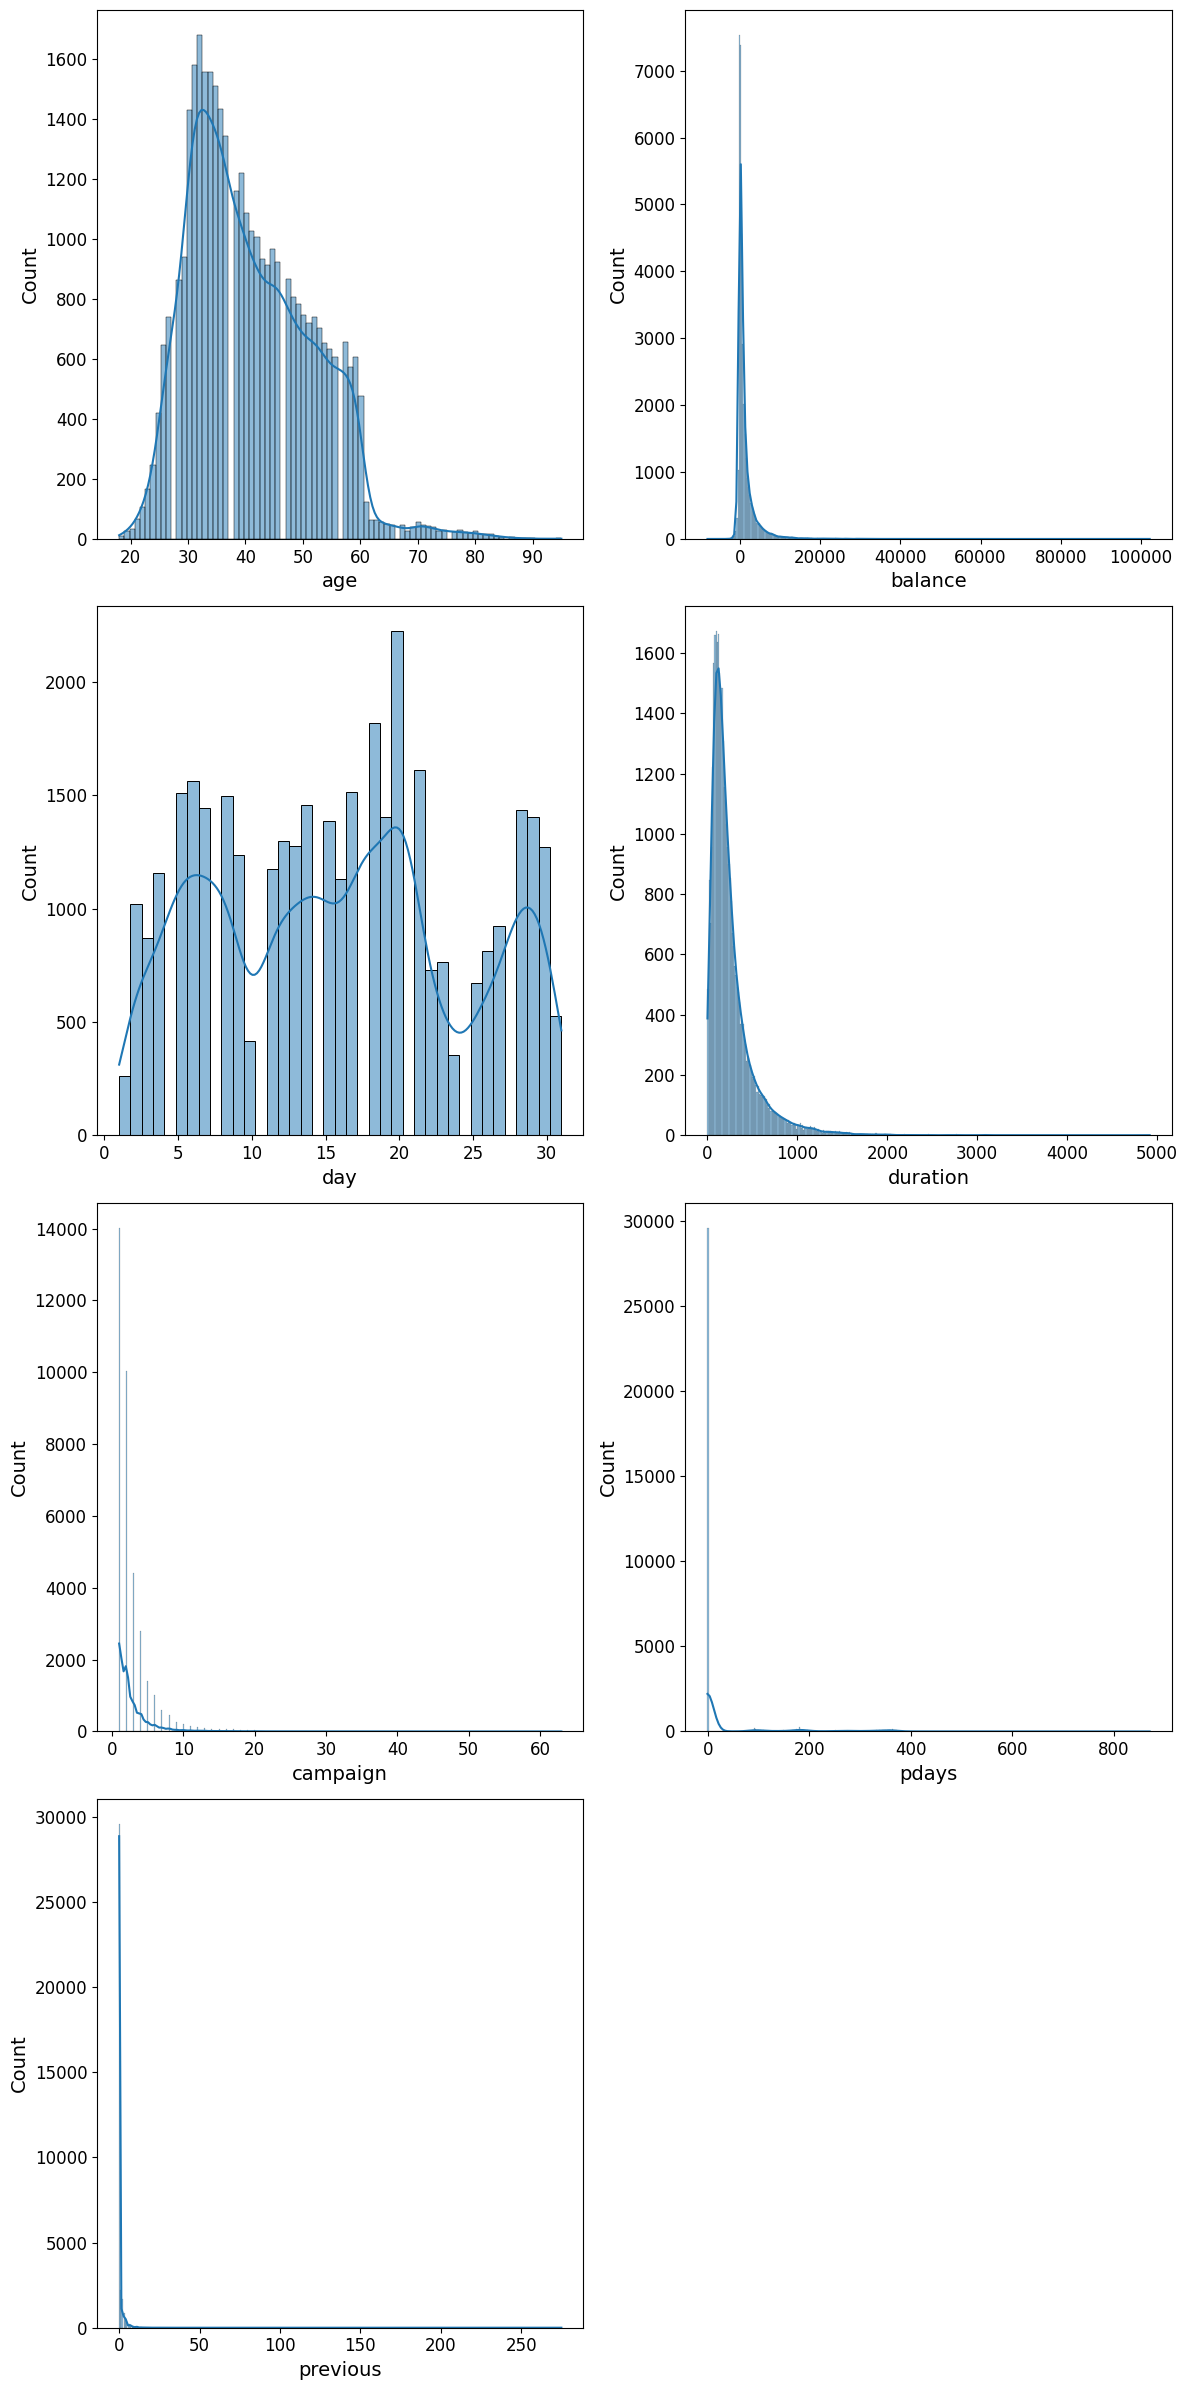

In [16]:
n_cols = 2
n_rows = (len(features_num) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 6 * n_rows))
axes = axes.flatten()
for i, num in enumerate(features_num):
    sns.histplot(train_set[num], kde=True, ax=axes[i])
# Ocultar ejes vacíos si hay un número impar de features
if len(features_num) % 2 != 0:
    axes[-1].set_visible(False)    

plt.tight_layout()
plt.show()

In [17]:
# Mantener balance transformado + crear binarias adicionales
train_set['balance_transformed'] = np.sign(train_set['balance']) * np.log1p(np.abs(train_set['balance']))
train_set['tiene_deuda'] = (train_set['balance'] < 0).astype(int)
train_set['balance_alto'] = (train_set['balance'] > train_set['balance'].median()).astype(int)

# Lo mismo para test
test_set['balance_transformed'] = np.sign(test_set['balance']) * np.log1p(np.abs(test_set['balance']))
test_set['tiene_deuda'] = (test_set['balance'] < 0).astype(int)
test_set['balance_alto'] = (test_set['balance'] > test_set['balance'].median()).astype(int)

In [18]:
# Para PDAYS (-1 significa "no contactado previamente"):
# Opción B: Sumar 2 para hacer todos positivos (así -1 → 1, 0 → 2, etc.)
train_set['pdays'] = np.log1p(train_set['pdays'] + 2)
test_set['pdays'] = np.log1p(test_set['pdays'] + 2)

In [19]:
nuevas_features = ['balance_transformed', 'tiene_deuda', 'balance_alto']
features_num = features_num.union(nuevas_features).drop("balance")

In [20]:
# Aplicamos logaritmo para conseguir una distribución gaussiana
train_set[['age', 'duration', 'campaign', 'previous']] = (train_set[['age', 'duration', 'campaign', 'previous']]).apply(np.log1p)
test_set[['age', 'duration', 'campaign', 'previous']] = (test_set[['age', 'duration', 'campaign', 'previous']]).apply(np.log1p)

In [22]:
print("Valores del target: ",df[target].unique())
print(features_num)
print(features_cat)
print(features_bin)

Valores del target:  ['no' 'yes']
Index(['age', 'balance_alto', 'balance_transformed', 'campaign', 'day',
       'duration', 'pdays', 'previous', 'tiene_deuda'],
      dtype='object')
Index(['job', 'marital', 'education', 'contact', 'month', 'poutcome'], dtype='object')
Index(['housing', 'loan'], dtype='object')


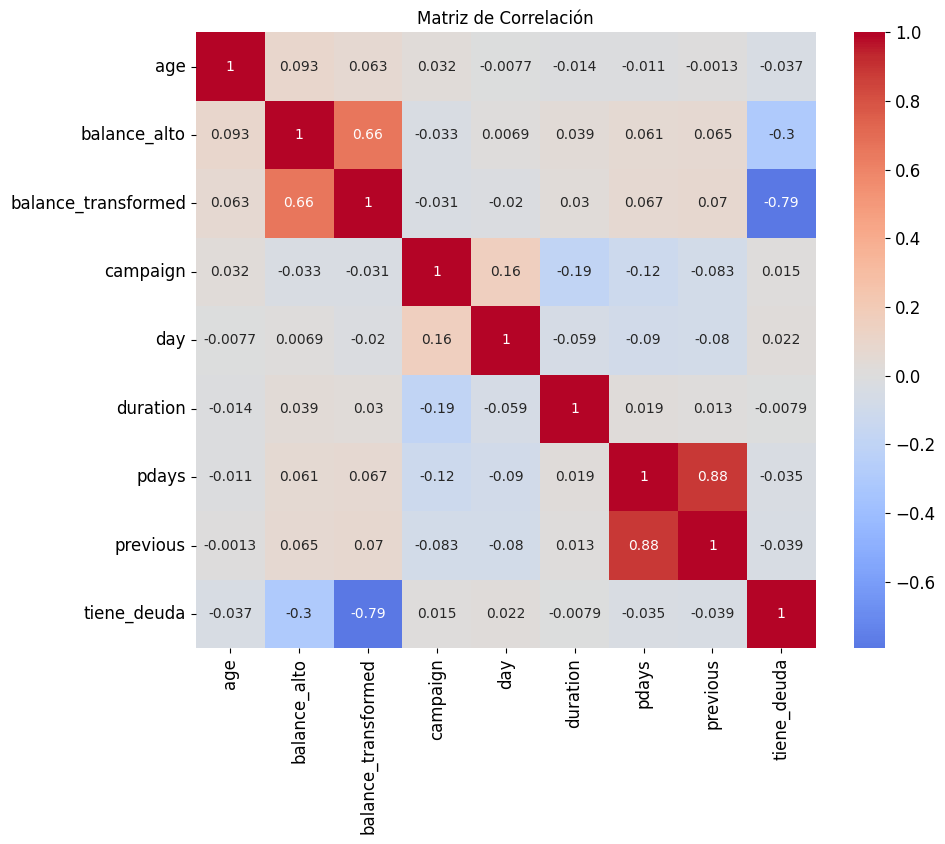

In [23]:
correlation_matrix = train_set[features_num].corr()

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

In [24]:
# Calcula VIF para confirmar
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = features_num
vif_data["VIF"] = [variance_inflation_factor(train_set[features_num].values, i) 
                   for i in range(len(features_num))]
print(vif_data)

               feature        VIF
0                  age  44.987991
1         balance_alto   4.626788
2  balance_transformed  14.984193
3             campaign   6.428924
4                  day   4.697492
5             duration  28.918713
6                pdays   7.727284
7             previous   5.258201
8          tiene_deuda   3.804814


In [ ]:
features_num= features_num.drop("balance_transformed")
features_num = features_num.drop('age')

In [28]:
features_num = features_num.union(['age'])
vif_data = pd.DataFrame()
vif_data["feature"] = features_num
vif_data["VIF"] = [variance_inflation_factor(train_set[features_num].values, i) 
                   for i in range(len(features_num))]
print(vif_data)

        feature        VIF
0           age  41.312389
1  balance_alto   2.225104
2      campaign   6.426238
3           day   4.697446
4      duration  28.747035
5         pdays   7.722033
6      previous   5.258128
7   tiene_deuda   1.197970


In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_set_scaled = pd.DataFrame(scaler.fit_transform(train_set[features_num]), columns= train_set[features_num].columns, index = train_set[features_num].index)
test_set_scaled =pd.DataFrame(scaler.transform(test_set[features_num]),columns= test_set[features_num].columns, index = test_set[features_num].index)

In [36]:
for col in train_set[features_cat]:
 print(f"{col}:\n{train_set[col].unique()}")

job:
['technician' 'student' 'unemployed' 'blue-collar' 'management' 'services'
 'admin.' 'retired' 'unknown' 'entrepreneur' 'housemaid' 'self-employed']
marital:
['divorced' 'single' 'married']
education:
['secondary' 'tertiary' 'primary' 'unknown']
contact:
['telephone' 'cellular' 'unknown']
month:
['aug' 'apr' 'jul' 'feb' 'jun' 'may' 'nov' 'mar' 'oct' 'jan' 'sep' 'dec']
poutcome:
['unknown' 'failure' 'other' 'success']


In [37]:
from sklearn.preprocessing import OneHotEncoder # Usamos Alternativa con sklearn (más control), en vez pd.get_dummies().
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_encoded_cat = encoder.fit_transform(train_set[features_cat])
test_encoded_cat = encoder.transform(test_set[features_cat])

encoded_column_names = encoder.get_feature_names_out(features_cat)

df_train_encoded_cat = pd.DataFrame(train_encoded_cat, columns = encoded_column_names, index=train_set.index )
df_test_encoded_cat = pd.DataFrame(test_encoded_cat,columns= encoded_column_names, index= test_set.index)

In [38]:
for col in train_set[features_bin]:
 print(f"{col}:\n{train_set[col].unique()}")

housing:
['no' 'yes']
loan:
['no' 'yes']


In [39]:
for col in features_bin:
    train_set[col] = train_set[col].map({'yes': 1, 'no': 0})
    test_set[col] = test_set[col].map({'yes': 1, 'no': 0})

In [43]:
print(type(train_set['y']))

<class 'pandas.core.series.Series'>


In [45]:
# UNIR TODO:
train_final = pd.concat([
    train_set_scaled,
    df_train_encoded_cat,
    train_set[features_bin],
    train_set['y']
], axis=1)

test_final = pd.concat([
    test_set_scaled,
    df_test_encoded_cat,
    test_set[features_bin],
    test_set['y']
], axis=1)

print(f"\nDataset final - Train: {train_final.shape}")
print(f"Dataset final - Test: {test_final.shape}")


Dataset final - Train: (36168, 49)
Dataset final - Test: (9043, 49)


In [48]:
train_final["y"] = train_final["y"].map({'yes': 1, 'no': 0})
test_final["y"] = test_final["y"].map({'yes': 1, 'no': 0})

In [49]:
print(train_final[target].unique())

[0 1]


In [50]:
X_train = train_final.drop("y", axis=1)
y_train = train_final["y"]
X_test = test_final.drop("y", axis=1)
y_test = test_final["y"]

# Confirmar que todo está bien
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

X_train: (36168, 48)
y_train: (36168,)
X_test: (9043, 48)
y_test: (9043,)


### A entrenar  
Crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
log_reg = LogisticRegression()
tree_clas = DecisionTreeClassifier()

tree_clas.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [61]:
print("Nivel profundidad. ",tree_clas.get_depth())
print(tree_clas.n_outputs_)
print(tree_clas.get_n_leaves())

from sklearn.metrics import classification_report
y_test_pred_tree = tree_clas.predict(X_test)

print("Arbol de decisión:","\n",classification_report(y_test,y_test_pred_tree))


Nivel profundidad.  36
1
3052
Arbol de decisión: 
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      7985
           1       0.48      0.50      0.49      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.71      0.71      9043
weighted avg       0.88      0.88      0.88      9043



In [62]:
hparam_grid_tree= {
    "max_depth": np.arange(5, 35, 5), 
    "min_samples_split":np.arange(500, 1000, 100),
    "min_samples_leaf": np.arange(500, 2501, 250),
    "class_weight" : ["balanced"]
}
from sklearn.model_selection import RandomizedSearchCV
random_search_tree = RandomizedSearchCV(tree_clas, # El modelo que quiero entrenar
                                   param_distributions= hparam_grid_tree, # El grid de parámetros
                                   random_state=42, # Semilla
                                   n_iter= 100 , # Nº de iteraciones del random search
                                   cv=5, # Folds del cross validation
                                   scoring="accuracy", # Métrica que quiero optimizar
                                   n_jobs = -1, # Paralelizar
                                   verbose= 2 # Ver el progreso
                                  )

random_search_tree.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced'], 'max_depth': array([ 5, 10..., 20, 25, 30]), 'min_samples_leaf': array([ 500, ..., 2250, 2500]), 'min_samples_split': array([500, 6...00, 800, 900])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross

In [63]:
y_test_pred_tree_b = random_search_tree.predict(X_test)
print("Arbol de decisión optimizado:","\n",classification_report(y_test,y_test_pred_tree_b))

Arbol de decisión optimizado: 
               precision    recall  f1-score   support

           0       0.96      0.80      0.87      7985
           1       0.34      0.77      0.47      1058

    accuracy                           0.80      9043
   macro avg       0.65      0.79      0.67      9043
weighted avg       0.89      0.80      0.83      9043



In [67]:
from sklearn.model_selection import GridSearchCV
grid_search_tree = GridSearchCV(tree_clas, # El modelo que quiero entrenar
                                param_grid= hparam_grid_tree, # El grid de parámetros
                                cv=5, # Folds del cross validation
                                scoring="accuracy", # Métrica que quiero optimizar
                                n_jobs = -1, # Paralelizar
                                verbose= 2 # Ver el progreso
                                  )

grid_search_tree.fit(X_train, y_train)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': array([ 5, 10..., 20, 25, 30]), 'min_samples_leaf': array([ 500, ..., 2250, 2500]), 'min_samples_split': array([500, 6...00, 800, 900])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more message

In [68]:
y_test_pred_tree_c = grid_search_tree.predict(X_test)
print("Arbol de decisión optimizado con grid_search:","\n",classification_report(y_test,y_test_pred_tree_c))

Arbol de decisión optimizado con grid_search: 
               precision    recall  f1-score   support

           0       0.96      0.80      0.87      7985
           1       0.34      0.77      0.47      1058

    accuracy                           0.80      9043
   macro avg       0.65      0.79      0.67      9043
weighted avg       0.89      0.80      0.83      9043



In [69]:
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [70]:
y_test_pred_logreg = log_reg.predict(X_test)

print("Regresión logística:","\n", classification_report(y_test, y_test_pred_logreg))

Regresión logística: 
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.66      0.37      0.47      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.67      0.71      9043
weighted avg       0.89      0.90      0.89      9043



Todos los modelos predicen muy bien quien va decir que no, los optimizados mejor. Sin embargo dejan pasar muchas repuestas positivas como negativas. Al optimizar los hiperparámetros, reducimos la cantidad de positivas que se nos escapan como negativas.  
El "accuracy" es mucho mayor con la Regresión Logística, incluso sin optimizar.  
Creo que hubiese sido mejor modelo, optimizando.
